imoprting libraries and loading data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

initial look at the dataset

In [2]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isna().sum())
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

Basic Grouping and Filtering

In [3]:
avg=df.groupby("Pclass")["Fare"].mean()
print(avg)
top_fares = df.sort_values("Fare", ascending=False).head(10)
print(top_fares[["Name", "Pclass", "Fare"]])

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64
                                                Name  Pclass      Fare
679               Cardeza, Mr. Thomas Drake Martinez       1  512.3292
258                                 Ward, Miss. Anna       1  512.3292
737                           Lesurer, Mr. Gustave J       1  512.3292
88                        Fortune, Miss. Mabel Helen       1  263.0000
438                                Fortune, Mr. Mark       1  263.0000
341                   Fortune, Miss. Alice Elizabeth       1  263.0000
27                    Fortune, Mr. Charles Alexander       1  263.0000
742            Ryerson, Miss. Susan Parker "Suzette"       1  262.3750
311                       Ryerson, Miss. Emily Borie       1  262.3750
299  Baxter, Mrs. James (Helene DeLaudeniere Chaput)       1  247.5208


Data Cleaning

In [4]:
#only when analysis requires complete age column, else keep the NaN values.
# df['age']=df['age'].fillna(df['age'].median())
#fixing the missing values in Embarked column
df=df.dropna(subset=['Embarked'])
#fixing the missing values in cabin column
df["Cabin_Known"]=df["Cabin"].notna()
df=df.drop(columns=["Cabin"])

print(df["Cabin_Known"].value_counts())

#standardizing the string columns
df["Sex"] = df["Sex"].str.strip().str.lower()
df["Name"]= df["Name"].str.strip().str.lower()

Cabin_Known
False    687
True     202
Name: count, dtype: int64


Feature Creation

In [6]:
df["FamilySize"]= df["SibSp"] + df["Parch"] + 1
df["IsAlone"]= df["FamilySize"] == 1

Data Validation After Cleaning

In [7]:
print(df.isna().sum())
print(df.duplicated().sum())
print(df.shape)
print(df.dtypes)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Cabin_Known      0
Family Size      0
FamilySize       0
IsAlone          0
dtype: int64
0
(889, 15)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
Cabin_Known       bool
Family Size      int64
FamilySize       int64
IsAlone           bool
dtype: object


outlier Detection

In [8]:
print(df["Fare"].describe())

count    889.000000
mean      32.096681
std       49.697504
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


Exploratory Data Analysis on the Cleaned Dataset

In [9]:
print("EDA")
print("Column Age's Mean: ", df['Age'].mean())
print("Column Age's Median: ", df['Age'].median())
print("Column Age's Mode: ", df['Age'].mode())
print("Column Age's Standard Deviation: ", df['Age'].std())
print("Column Age's Minimum: ", df['Age'].min())
print("Column Age's Maximum: ", df['Age'].max())
print("Column Age's 25th Percentile: ", df['Age'].quantile(0.25))
print("Column Age's 50th Percentile: ", df['Age'].quantile(0.50))
print("Column Age's 75th Percentile: ", df['Age'].quantile(0.75))
print("Survival Rate by Sex:")
grpbysex=df.groupby("Sex")["Survived"].mean()*100
print(grpbysex)
grpbyclass=df.groupby("Pclass")["Survived"].mean()*100
print("Survival Rate by Class:")
print(grpbyclass)
print(df["Age"].corr(df["Fare"]))

EDA
Column Age's Mean:  29.64209269662921
Column Age's Median:  28.0
Column Age's Mode:  0    24.0
Name: Age, dtype: float64
Column Age's Standard Deviation:  14.49293290032352
Column Age's Minimum:  0.42
Column Age's Maximum:  80.0
Column Age's 25th Percentile:  20.0
Column Age's 50th Percentile:  28.0
Column Age's 75th Percentile:  38.0
Survival Rate by Sex:
Sex
female    74.038462
male      18.890815
Name: Survived, dtype: float64
Survival Rate by Class:
Pclass
1    62.616822
2    47.282609
3    24.236253
Name: Survived, dtype: float64
0.09314251789411514


Visualisations

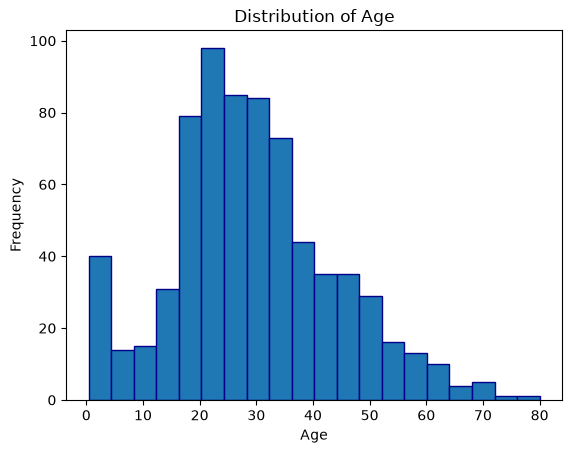

Survival Rate by Sex:
Sex
female    74.038462
male      18.890815
Name: Survived, dtype: float64


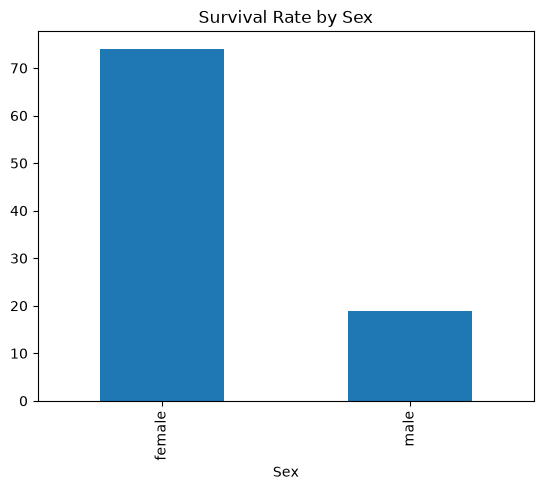

Survival Rate by Class:
Pclass
1    62.616822
2    47.282609
3    24.236253
Name: Survived, dtype: float64


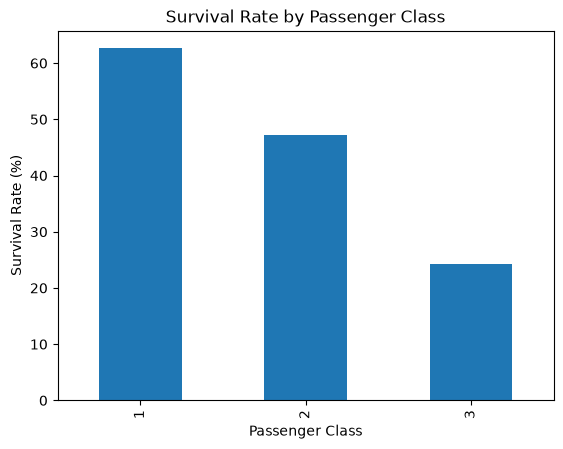

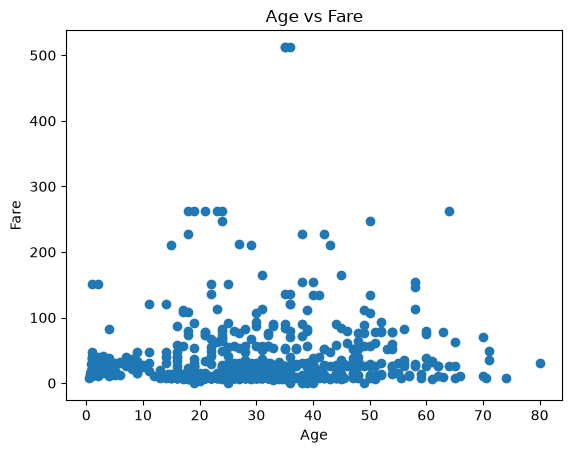

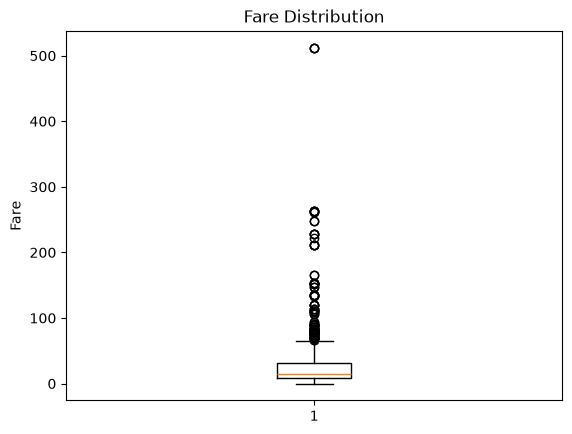

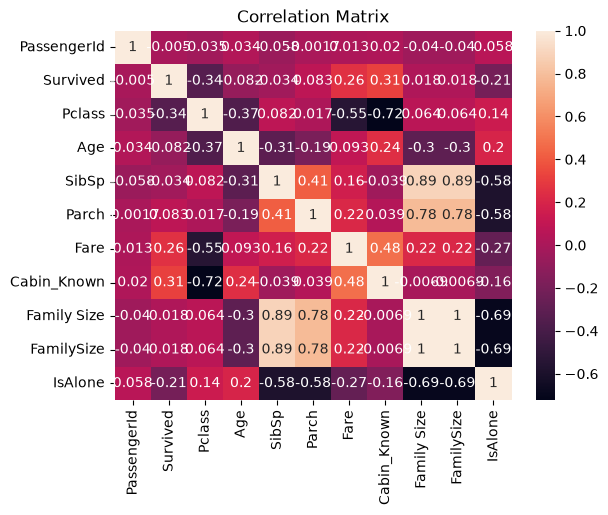

In [10]:
plt.hist(df["Age"],bins=20,edgecolor='darkblue')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print("Survival Rate by Sex:")
grpbysex=df.groupby("Sex")["Survived"].mean()*100
print(grpbysex)
grpbysex.plot(kind="bar",title="Survival Rate by Sex")
plt.show()

grpbyclass=df.groupby("Pclass")["Survived"].mean()*100
print("Survival Rate by Class:")
print(grpbyclass)
plt.figure()
grpbyclass.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.show()

plt.scatter(df["Age"],df["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

plt.boxplot(df["Fare"])
plt.title("Fare Distribution")
plt.ylabel("Fare")
plt.show()

correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()